# FRED macro panel and Adaptive HFA

A compact macroeconomic example using public FRED series obtained through `pandas-datareader`. This is not a replacement for the full FRED-MD transformation table, but it shows the end-to-end workflow with openly accessible data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as web

import pyhofa


In [2]:
series = [
    "INDPRO",    # industrial production
    "PAYEMS",    # nonfarm payrolls
    "UNRATE",    # unemployment rate
    "CPIAUCSL",  # CPI
    "PCEPI",     # PCE price index
    "FEDFUNDS",  # policy rate
    "GS10",      # 10y Treasury yield
    "HOUST",     # housing starts
    "UMCSENT",   # consumer sentiment
    "SP500",     # S&P 500
]
raw = web.DataReader(series, "fred", start="1990-01-01")
monthly = raw.resample("ME").last().ffill()
monthly.tail()


/tmp/ipykernel_190605/2370323221.py:13: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  raw = web.DataReader(series, "fred", start="1990-01-01")


,INDPRO,PAYEMS,UNRATE,CPIAUCSL,PCEPI,FEDFUNDS,GS10,HOUST,UMCSENT,SP500
DATE,,,,,,,,,,
2026-04-30,102.4196,158798.0,4.3,332.407,130.932,3.64,4.32,1414.0,49.8,7209.01
2026-05-31,102.5606,158861.0,4.3,333.979,131.535,3.63,4.48,1199.0,44.8,7580.06
2026-06-30,102.6395,158881.0,4.2,332.568,131.392,3.63,4.47,1427.0,49.5,7499.36
2026-07-31,102.6395,158858.0,4.1,332.813,131.392,3.63,4.60,1427.0,49.5,7489.72
2026-08-31,102.6395,158858.0,4.1,332.813,131.392,3.63,4.60,1427.0,49.5,7748.50


In [3]:
growth = ["INDPRO", "PAYEMS", "CPIAUCSL", "PCEPI", "HOUST", "SP500"]
rates = ["UNRATE", "FEDFUNDS", "GS10"]

panel = pd.DataFrame(index=monthly.index)
for col in growth:
    panel[col] = np.log(monthly[col].where(monthly[col] > 0)).diff()
for col in rates:
    panel[col] = monthly[col].diff()
panel["UMCSENT"] = np.log(monthly["UMCSENT"].where(monthly["UMCSENT"] > 0)).diff()

panel = panel.dropna()
panel = (panel - panel.mean()) / panel.std(ddof=1)
panel.tail()


,INDPRO,PAYEMS,CPIAUCSL,PCEPI,HOUST,SP500,UNRATE,FEDFUNDS,GS10,UMCSENT
DATE,,,,,,,,,,
2026-04-30,0.455766,0.010815,1.307047,0.795895,-0.859851,1.996038,0.006542,-0.144042,0.224283,-1.020625
2026-05-31,0.064109,-0.027233,0.715845,1.060172,-1.903460,0.892353,0.006542,-0.197557,0.676196,-1.634795
2026-06-30,0.027491,-0.046461,-2.468477,-1.688232,1.970379,-0.480279,-0.091589,-0.144042,-0.177418,1.697769
2026-07-31,-0.018920,-0.065682,-0.700482,-1.162139,-0.018827,-0.268000,-0.091589,-0.144042,0.525558,0.080463
2026-08-31,-0.018920,-0.055401,-0.962441,-1.162139,-0.018827,0.526689,0.006542,-0.144042,-0.127205,0.080463


In [4]:
X = panel.to_numpy()
er = pyhofa.m2_select(X, method="ER", rmax=5, modified=True)
ger3 = pyhofa.m3_select(X, method="GER3", rmax=5)

{
    "ER factors": er.R,
    "GER3 total": ger3.R,
    "GER3 non-Gaussian": ger3.Rh,
    "GER3 Gaussian": ger3.Rg,
}


{'ER factors': 1, 'GER3 total': 2, 'GER3 non-Gaussian': 1, 'GER3 Gaussian': 1}

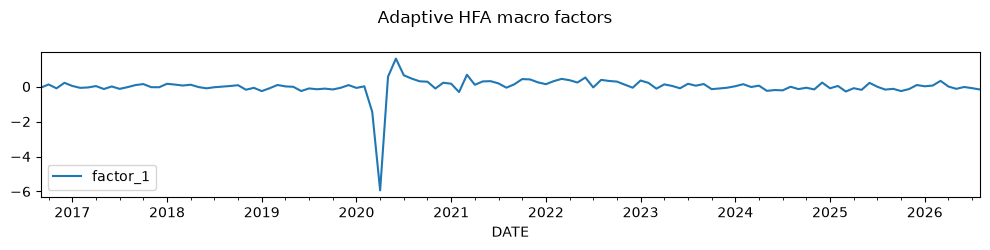

In [5]:
r = max(1, min(3, er.R, X.shape[1] - 1))
result = pyhofa.adaptive_hfa(X, r=r, max_order=3)

factor_df = pd.DataFrame(
    result.factors,
    index=panel.index,
    columns=[f"factor_{i+1}" for i in range(r)],
)
factor_df.plot(subplots=True, figsize=(10, 2.5 * r), title="Adaptive HFA macro factors")
plt.tight_layout()
plt.show()


In [6]:
result.factor_contribution_ratios


{2: 0.46686338712779046, 3: 0.9896197456369135}

For research using the official FRED-MD panel, apply the McCracken-Ng transformation codes to the full release vintage before estimation. This notebook deliberately stays self-contained and uses ordinary FRED endpoints.
